<a href="https://colab.research.google.com/github/jiffy-jacob/temperature-prediction-using-RNN/blob/main/weathertemp_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Building a SimpleRNN Model for Weather Temperature Prediction
##Objective
The goal of this assignment is to design, implement, and evaluate a Recurrent Neural Network
(RNN) model (using SimpleRNN) to forecast the next day’s temperature based on past weather
data.

###Dataset
Use the Daily Weather Dataset

● Example: Daily Weather Dataset – Kaggle

● Key Features:

○ Date

○ Temperature (target variable)

○ Humidity

○ Wind Speed

○ Pressure (optional)

##Tasks
###Part A: Data Understanding and Preprocessing
1. Load the dataset and explore:

○ Display first 10 rows.

○ Plot temperature trends over time.

○ Check for missing values.

2. Preprocess the data:

○ Handle missing values (impute/remove).

○ Normalize values using MinMaxScaler (so RNN converges faster).

○ Create input sequences:

■ Use past 7–14 days’ weather data (temperature, humidity, wind speed)as input.

■ Target: next day’s temperature.

○ Split dataset into train, validation, and test sets.

###Part B: RNN Model Development
3. Build a SimpleRNN model using TensorFlow/Keras:

○ Input layer (with shape = sequence length × number of features).

○ SimpleRNN layer (e.g., 32–64 units).

○ Dropout layer (optional, to avoid overfitting).

○ Dense layer with 1 unit (linear activation for regression).

4. Compile the model:

○ Loss: Mean Squared Error (MSE).

○ Optimizer: Adam.

○ Metrics: Mean Absolute Error (MAE).

5. Train the model on training data:
○ Batch size: 32

○ Epochs: 50–100

○ Use validation data to monitor performance.

○ Plot training vs validation loss curves.

###Part C: Model Evaluation & Forecasting
6. Evaluate the model on the test set:

○ Calculate RMSE, MAE, and R2 score.

○ Plot predicted vs actual temperatures for the test period.

7. Forecast the next 7 days of temperature using the trained model and visualize
predictions vs recent historical data.

#Part A: Data Understanding and Preprocessing


##1. Load dataset and Explore

In [1]:
#Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


In [2]:
#Load dataset
from google.colab import drive
df=pd.read_csv("/content/drive/MyDrive/weatherHistory.csv")
df.head(10)

,Formatted Date,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary
0,2006-04-01 00:00:00.000 +0200,Partly Cloudy,rain,9.472222,7.388889,0.89,14.1197,251.0,15.8263,0.0,1015.13,Partly cloudy throughout the day.
1,2006-04-01 01:00:00.000 +0200,Partly Cloudy,rain,9.355556,7.227778,0.86,14.2646,259.0,15.8263,0.0,1015.63,Partly cloudy throughout the day.
2,2006-04-01 02:00:00.000 +0200,Mostly Cloudy,rain,9.377778,9.377778,0.89,3.9284,204.0,14.9569,0.0,1015.94,Partly cloudy throughout the day.
3,2006-04-01 03:00:00.000 +0200,Partly Cloudy,rain,8.288889,5.944444,0.83,14.1036,269.0,15.8263,0.0,1016.41,Partly cloudy throughout the day.
4,2006-04-01 04:00:00.000 +0200,Mostly Cloudy,rain,8.755556,6.977778,0.83,11.0446,259.0,15.8263,0.0,1016.51,Partly cloudy throughout the day.
5,2006-04-01 05:00:00.000 +0200,Partly Cloudy,rain,9.222222,7.111111,0.85,13.9587,258.0,14.9569,0.0,1016.66,Partly cloudy throughout the day.
6,2006-04-01 06:00:00.000 +0200,Partly Cloudy,rain,7.733333,5.522222,0.95,12.3648,259.0,9.9820,0.0,1016.72,Partly cloudy throughout the day.
7,2006-04-01 07:00:00.000 +0200,Partly Cloudy,rain,8.772222,6.527778,0.89,14.1519,260.0,9.9820,0.0,1016.84,Partly cloudy throughout the day.
8,2006-04-01 08:00:00.000 +0200,Partly Cloudy,rain,10.822222,10.822222,0.82,11.3183,259.0,9.9820,0.0,1017.37,Partly cloudy throughout the day.
9,2006-04-01 09:00:00.000 +0200,Partly Cloudy,rain,13.772222,13.772222,0.72,12.5258,279.0,9.9820,0.0,1017.22,Partly cloudy throughout the day.


In [3]:
#check dataset information
# Dataset shape
print("Dataset Shape:", df.shape)

# Column names
print("\nColumns:")
print(df.columns.tolist())

# Dataset information
print("\nDataset Info:")
df.info()

Dataset Shape: (96453, 12)

Columns:
['Formatted Date', 'Summary', 'Precip Type', 'Temperature (C)', 'Apparent Temperature (C)', 'Humidity', 'Wind Speed (km/h)', 'Wind Bearing (degrees)', 'Visibility (km)', 'Loud Cover', 'Pressure (millibars)', 'Daily Summary']

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96453 entries, 0 to 96452
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Formatted Date            96453 non-null  object 
 1   Summary                   96453 non-null  object 
 2   Precip Type               95936 non-null  object 
 3   Temperature (C)           96453 non-null  float64
 4   Apparent Temperature (C)  96453 non-null  float64
 5   Humidity                  96453 non-null  float64
 6   Wind Speed (km/h)         96453 non-null  float64
 7   Wind Bearing (degrees)    96453 non-null  float64
 8   Visibility (km)           96453 non-null  float64
 9   Loud

In [4]:
#check missing values
print("\nMissing Values:")
print(df.isnull().sum())



Missing Values:
Formatted Date                0
Summary                       0
Precip Type                 517
Temperature (C)               0
Apparent Temperature (C)      0
Humidity                      0
Wind Speed (km/h)             0
Wind Bearing (degrees)        0
Visibility (km)               0
Loud Cover                    0
Pressure (millibars)          0
Daily Summary                 0
dtype: int64


In [5]:
#convert date column
df['Formatted Date']=pd.to_datetime(df['Formatted Date'],utc=True)
df['date']=df['Formatted Date'].dt.date

In [6]:
#creating daily weather data
daily_df=df.groupby("date")[["Temperature (C)","Humidity","Wind Speed (km/h)"
]].mean().reset_index()
daily_df.head(10)

,date,Temperature (C),Humidity,Wind Speed (km/h)
0,2005-12-31,0.577778,0.890000,17.114300
1,2006-01-01,4.075000,0.817083,21.229192
2,2006-01-02,5.263194,0.847083,17.824713
3,2006-01-03,2.340509,0.897083,7.726658
4,2006-01-04,2.251852,0.906667,12.152817
5,2006-01-05,2.703935,0.951250,8.991179
6,2006-01-06,2.550463,0.945833,5.729588
7,2006-01-07,0.877083,0.935833,6.589596
8,2006-01-08,-1.231713,0.868750,5.397525
9,2006-01-09,-1.693287,0.792500,5.113762


In [7]:
#check new daily_df
print("Daily Dataset Shape:", daily_df.shape)

print("\nMissing Values:")
print(daily_df.isnull().sum())

print("\nDataset Information:")
daily_df.info()

Daily Dataset Shape: (4019, 4)

Missing Values:
date                 0
Temperature (C)      0
Humidity             0
Wind Speed (km/h)    0
dtype: int64

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4019 entries, 0 to 4018
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   date               4019 non-null   object 
 1   Temperature (C)    4019 non-null   float64
 2   Humidity           4019 non-null   float64
 3   Wind Speed (km/h)  4019 non-null   float64
dtypes: float64(3), object(1)
memory usage: 125.7+ KB


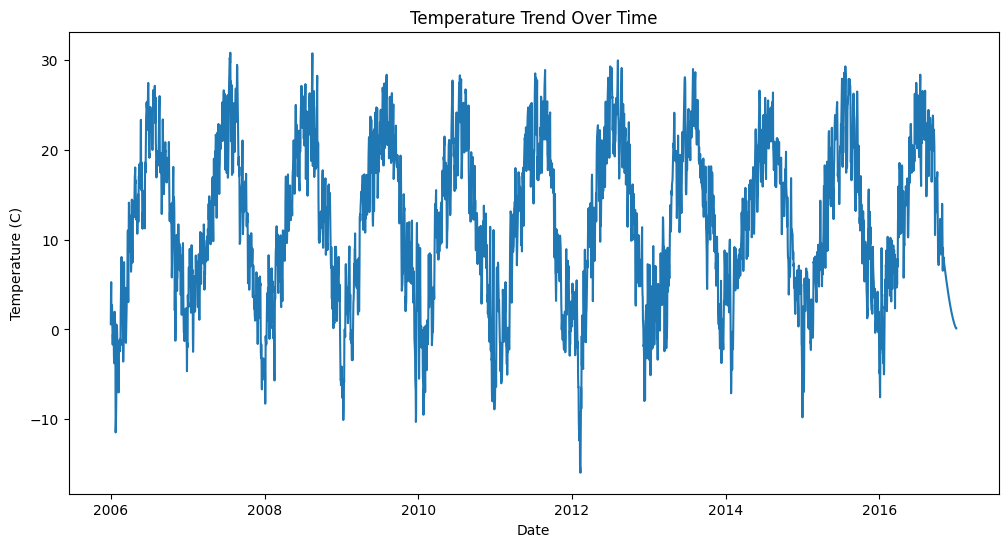

In [8]:
#Temperature Trend Plot
plt.figure(figsize=(12, 6))
plt.plot(daily_df['date'], daily_df['Temperature (C)'])
plt.title('Temperature Trend Over Time')
plt.xlabel('Date')
plt.ylabel("Temperature (C)")
plt.show()

In [9]:
#check missing values
daily_df.isnull().sum()

,0
date,0
Temperature (C),0
Humidity,0
Wind Speed (km/h),0


##2. Preprocess the data

In [10]:
#Normalize the features using MinMaxScaler
features=[
    "Temperature (C)",
    "Humidity",
    "Wind Speed (km/h)"
]
scaler=MinMaxScaler()
daily_df[features]=scaler.fit_transform(daily_df[features])
scaled_df = pd.DataFrame(
    daily_df,
    columns=features
)


In [11]:
scaled_df.head()

,Temperature (C),Humidity,Wind Speed (km/h)
0,0.353548,0.849462,0.434654
1,0.428318,0.744922,0.546415
2,0.453722,0.787933,0.453949
3,0.391235,0.859618,0.179685
4,0.389340,0.873357,0.299900


In [12]:
#create input sequences
X = []
y = []

for i in range(7, len(daily_df)):

    # Previous 7 days
    X.append(scaled_df.iloc[i-7:i].values)

    # Next day's temperature
    y.append(scaled_df.iloc[i]["Temperature (C)"])

In [13]:
X = np.array(X)
y = np.array(y)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (4012, 7, 3)
y shape: (4012,)


In [14]:
#Split data into train validation and test sets
train_size = int(0.7 * len(X))
val_size = int(0.15 * len(X))

X_train = X[:train_size]
y_train = y[:train_size]

X_val = X[train_size:train_size + val_size]
y_val = y[train_size:train_size + val_size]

X_test = X[train_size + val_size:]
y_test = y[train_size + val_size:]

print("Training Data:", X_train.shape)
print("Validation Data:", X_val.shape)
print("Test Data:", X_test.shape)

Training Data: (2808, 7, 3)
Validation Data: (601, 7, 3)
Test Data: (603, 7, 3)


#Part B: RNN Model Development

##3. Build a Simple RNN Model

In [15]:
model = Sequential()
model.add(SimpleRNN(32,
        input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(Dropout(0.2))  #to reduce overfitting
model.add(Dense(1))  #for predicting temperature
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 32)             │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,185 (4.63 KB)

 Trainable params: 1,185 (4.63 KB)

 Non-trainable params: 0 (0.00 B)

##4. Compile the model

In [16]:
model.compile(optimizer="adam",loss="mse",metrics=["mae"])

##5. Train the model

In [18]:
#train the model
history=model.fit(X_train,y_train,validation_data=(X_val,y_val),epochs=100,batch_size=32)

Epoch 1/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0027 - mae: 0.0405 - val_loss: 0.0017 - val_mae: 0.0328
Epoch 2/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0028 - mae: 0.0410 - val_loss: 0.0017 - val_mae: 0.0327
Epoch 3/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0028 - mae: 0.0410 - val_loss: 0.0018 - val_mae: 0.0337
Epoch 4/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0028 - mae: 0.0412 - val_loss: 0.0017 - val_mae: 0.0325
Epoch 5/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0026 - mae: 0.0396 - val_loss: 0.0017 - val_mae: 0.0326
Epoch 6/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0027 - mae: 0.0407 - val_loss: 0.0018 - val_mae: 0.0338
Epoch 7/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0026 - mae: 0.0398 - val_loss: 0.0017 - val_mae: 0.0330
Epoch 8/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0027 - mae: 0.0410 - val_loss: 0.0017 - val_mae: 0.0329
Epoch 9/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.002

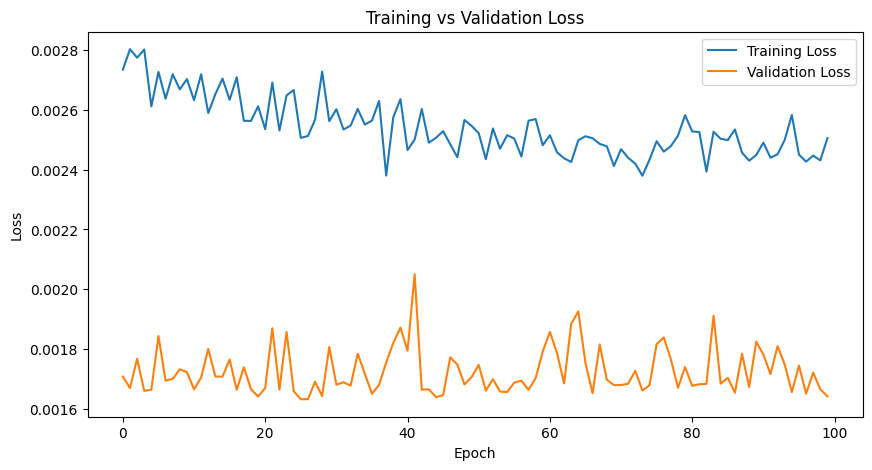

In [19]:
#plot training and validation loss
plt.figure(figsize=(10, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

#Part C: Model Evaluation & Forecasting

##6. Evaluate the model

In [20]:
y_pred=model.predict(X_test)

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


*Since the values were scaled using MinMaxScaler, we need to convert the predicted and actual temperatures back to the original Celsius scale.Because the scaler was fitted on 3 features, the simplest approach is to use the temperature column's minimum and maximum values:*

In [21]:
temp_min = daily_df["Temperature (C)"].min()
temp_max = daily_df["Temperature (C)"].max()

y_test_actual = y_test * (temp_max - temp_min) + temp_min
y_pred_actual = y_pred.flatten() * (temp_max - temp_min) + temp_min

In [22]:
#Calculate RMSE, MAE and R2
mae = mean_absolute_error(y_test_actual, y_pred_actual)

rmse = np.sqrt(
    mean_squared_error(y_test_actual, y_pred_actual)
)

r2 = r2_score(y_test_actual, y_pred_actual)

print("MAE:", mae)
print("RMSE:", rmse)
print("R² Score:", r2)

MAE: 0.030990487566736998
RMSE: 0.040975631191665904
R² Score: 0.948642371532626


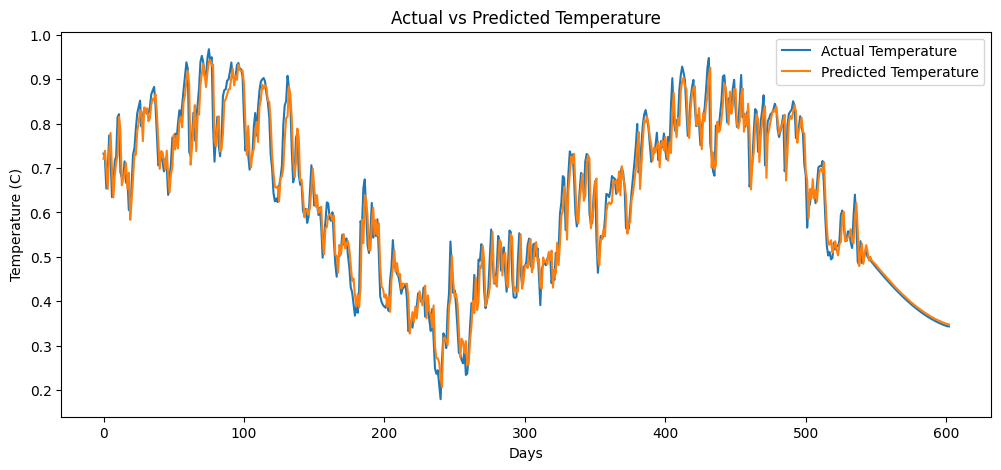

In [23]:
#plot actual Vs Predicted Temperature
plt.figure(figsize=(12, 5))
plt.plot(y_test_actual, label="Actual Temperature")
plt.plot(y_pred_actual, label="Predicted Temperature")
plt.title("Actual vs Predicted Temperature")
plt.xlabel("Days")
plt.ylabel("Temperature (C)")
plt.legend()
plt.show()

##7. Forecast the next 7 days of temperature using the trained model and visualize predictions vs recent historical data.

*For future forecasting, we start with the last 7 days of available weather data. The model predicts the next day's temperature, then that prediction is added to the sequence to predict the following day.Because we do not know future humidity and wind speed, we will keep the latest values constant for these features during the 7-day forecast.*

In [24]:
# Take the last 7 days of data

last_sequence = scaled_df.iloc[-7:].values.copy()

future_predictions = []

for i in range(7):

    # Predict next day's temperature
    prediction = model.predict(
        last_sequence.reshape(1, 7, 3),
        verbose=0
    )[0][0]

    future_predictions.append(prediction)

    # Create next day's input
    next_day = last_sequence[-1].copy()

    # Update temperature with predicted value
    next_day[0] = prediction

    # Add the new day and remove the oldest day
    last_sequence = np.vstack([
        last_sequence[1:],
        next_day
    ])

In [25]:
#convert Forecasts back to Celsius
future_predictions = np.array(future_predictions)
future_predictions_actual = (
    future_predictions * (temp_max - temp_min) + temp_min)
print("Next 7 Days Temperature Forecast:")
for i, temp in enumerate(future_predictions_actual, start=1):
    print(f"Day {i}: {temp:.2f} °C")

Next 7 Days Temperature Forecast:
Day 1: 0.35 °C
Day 2: 0.35 °C
Day 3: 0.36 °C
Day 4: 0.36 °C
Day 5: 0.36 °C
Day 6: 0.36 °C
Day 7: 0.36 °C


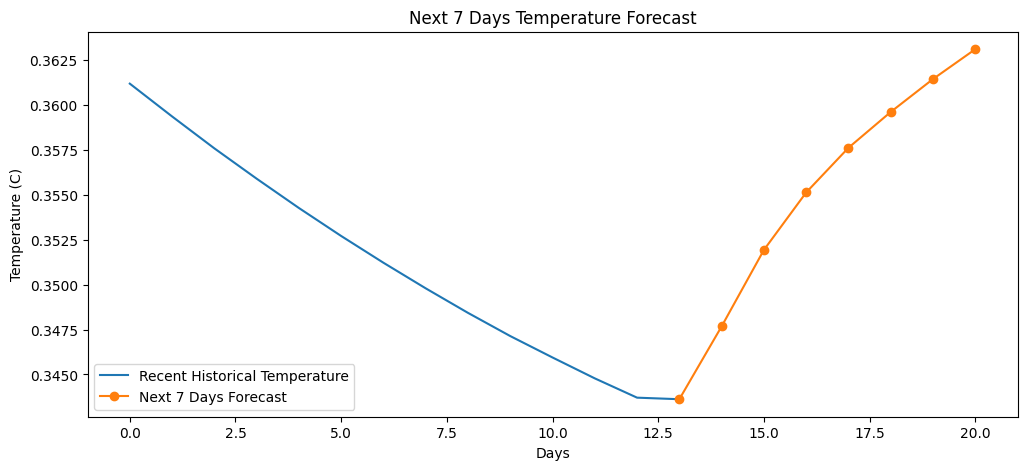

In [26]:
#Visualize Forecast vs Recent historical data
recent_temperatures = daily_df["Temperature (C)"].tail(14).values

plt.figure(figsize=(12, 5))

# Recent historical temperatures
plt.plot(
    range(14),
    recent_temperatures,
    label="Recent Historical Temperature"
)

# Forecast: last actual value + 7 predicted values
forecast_values = np.concatenate([
    [recent_temperatures[-1]],
    future_predictions_actual
])

plt.plot(
    range(13, 21),
    forecast_values,
    label="Next 7 Days Forecast",
    marker="o"
)

plt.title("Next 7 Days Temperature Forecast")
plt.xlabel("Days")
plt.ylabel("Temperature (C)")
plt.legend()

plt.show()
